In [1]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers


In [2]:
# 1. Load Data

In [3]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
  'data/rps',
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  subset="training",
  validation_split=0.2,
  seed=42
)

Found 3655 files belonging to 3 classes.
Using 2924 files for training.


In [5]:
val_ds = keras.utils.image_dataset_from_directory(
  'data/rps',
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
  subset="validation",
  validation_split=0.2,
  seed=42
)

Found 3655 files belonging to 3 classes.
Using 731 files for validation.


In [6]:
test_ds = keras.utils.image_dataset_from_directory(
  'data/rps-test-set',
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE,
)

Found 577 files belonging to 3 classes.


In [7]:
class_names = train_ds.class_names
print(class_names)

['paper', 'rock', 'scissors']


In [9]:
num_classes = len(class_names)
print(num_classes)

3


In [10]:
#  2. optimze input pipeline

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [12]:
# 3. Data Augmentation

In [14]:
data_aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),

    # New stuff that actually helps
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomBrightness(0.2),

    # Optional but useful
    keras.layers.GaussianNoise(0.05)
])

In [195]:
# 4. Build CNN From Scratch

In [15]:
model  = keras.Sequential([
  layers.Input(shape=(150, 150, 3)),
  
  data_aug,
  
  layers.Rescaling(1.0/255),
  
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  
  layers.Dense(128, activation='relu'),
  
  layers.Dense(num_classes, activation='softmax')
])

In [16]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,307 (10.22 MB)

 Trainable params: 2,678,307 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=50,
  callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
  )

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.4791 - loss: 1.0543 - val_accuracy: 0.6854 - val_loss: 0.7380
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.6867 - loss: 0.7339 - val_accuracy: 0.8126 - val_loss: 0.4918
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7709 - loss: 0.5607 - val_accuracy: 0.8044 - val_loss: 0.4516
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8163 - loss: 0.4541 - val_accuracy: 0.9261 - val_loss: 0.2373
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.8748 - loss: 0.3345 - val_accuracy: 0.9466 - val_loss: 0.1489
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8806 - loss: 0.3099 - val_accuracy: 0.9070 - val_loss: 0.2525
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.8926 - loss: 0.2771 - val_accuracy: 0.9781 - val_loss: 0.0998
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9251 - loss: 0.2151 - val_accuracy: 0.9494 - 

In [19]:
test_loss, test_acc = model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0055


In [20]:
test_acc

1.0

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [22]:
print(acc)
print(val_acc)
print(loss)
print(val_loss)

[0.47913816571235657, 0.6867305040359497, 0.770861804485321, 0.8163474798202515, 0.8748289942741394, 0.8806429505348206, 0.892612874507904, 0.9251025915145874, 0.9206566214561462, 0.9353625178337097, 0.9370725154876709, 0.9363884925842285, 0.9531463980674744, 0.9432284832000732, 0.952462375164032, 0.9593023061752319, 0.9545143842697144, 0.9586183428764343, 0.9688782691955566, 0.9647743105888367, 0.9678522348403931, 0.9616963267326355, 0.9822161197662354, 0.9787961840629578, 0.9808481335639954, 0.9811901450157166, 0.9781121611595154, 0.9835841059684753, 0.9774281978607178, 0.979138195514679, 0.9774281978607178, 0.9764021635055542, 0.9811901450157166, 0.9774281978607178]
[0.6853625178337097, 0.8125854730606079, 0.804377555847168, 0.9261285662651062, 0.9466484189033508, 0.9069767594337463, 0.9781121611595154, 0.9493843913078308, 0.9534883499145508, 0.9822161197662354, 0.9808481335639954, 0.9616963267326355, 0.9507523775100708, 0.9822161197662354, 0.9589603543281555, 0.9890561103820801, 0.

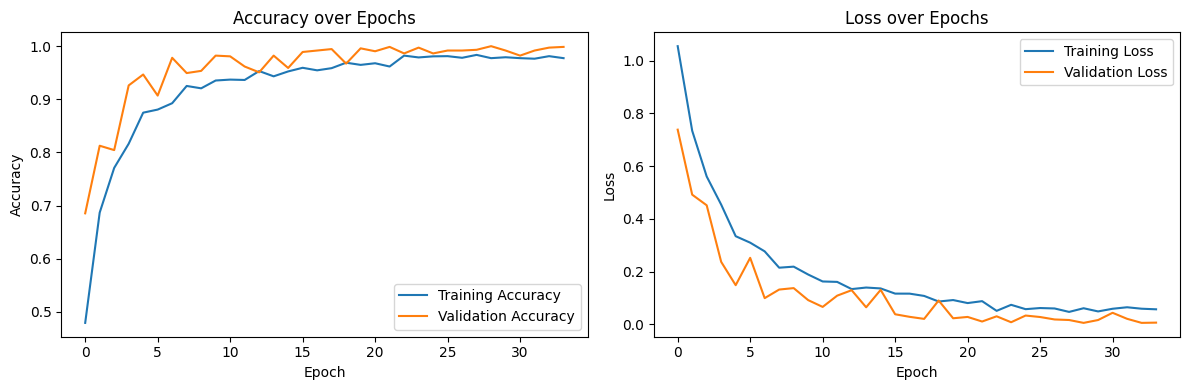

In [23]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Save model
model.save('./models/rps_cnn_model.keras')
print("Model saved to rps_cnn_model.keras")

Model saved to rps_cnn_model.keras
